# Section1 — Load Reuters Dataset, Preprocess and building inverted index

In [3]:
import nltk
from nltk.corpus import reuters
from nltk import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from collections import defaultdict, Counter
import re
import time

nltk.download('reuters')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# --- Preprocessing Functions (From part 2)---

# 1. Lowercase
def apply_lowercase(tokens):
    return [t.lower() for t in tokens]

# 2. Remove Punctuations & Numbers
punct_num_regex = re.compile(r'[^a-zA-Z]')
def remove_punct_and_numbers(tokens):
    cleaned_tokens = []
    for t in tokens:
        new_t = punct_num_regex.sub('', t)
        if new_t != '':
            cleaned_tokens.append(new_t)
    return cleaned_tokens

# 3. Stopwords (with a little modification)
stop_words = set(stopwords.words('english'))   # using NLTK's list instead of 50 words list

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

# 4. Stemming
ps = PorterStemmer()
def apply_stemming(tokens):
    return [ps.stem(t) for t in tokens]

# 5. Min Length Check (new function suggested by Gemini-3-pro)
def filter_short_tokens(tokens, min_len=3):
    return [t for t in tokens if len(t) >= min_len]

def preprocess_pipeline(tokens):
    """
    Recommended Preprocessing Pipeline:
    Lowercase -> Remove Punct/Num -> Stopwords -> Stemming -> Short Token Filter
    """
    tokens = apply_lowercase(tokens)
    tokens = remove_punct_and_numbers(tokens)
    tokens = remove_stopwords(tokens)
    tokens = apply_stemming(tokens)
    tokens = filter_short_tokens(tokens)
    return tokens

# --- Build Index with TF ---
def build_tf_inverted_index(documents):
    """
    Builds an inverted index that stores Term Frequency (TF).
    Structure: {term: [(doc_id1, tf1), ...]}
    """
    inverted = defaultdict(list)

    total_docs = len(documents)
    print(f"Indexing {total_docs} documents...")

    for doc_id, tokens in documents:
        term_counts = Counter(tokens)

        for term, tf in term_counts.items():
            inverted[term].append((doc_id, tf))

    return inverted

if __name__ == "__main__":
    start_time = time.time()
    doc_ids = reuters.fileids()

    documents_data = []

    for doc_id in doc_ids:
        raw_text = reuters.raw(doc_id)
        tokens = word_tokenize(raw_text)
        processed_tokens = preprocess_pipeline(tokens)
        documents_data.append((doc_id, processed_tokens))

    tf_index = build_tf_inverted_index(documents_data)

    end_time = time.time()

    vocab_size = len(tf_index)

    print("\n" + "="*40)
    print("STEP 1 COMPLETE")
    print("="*40)
    print(f"Time Taken        : {end_time - start_time:.2f} seconds")
    print(f"Vocabulary Size   : {vocab_size}")

    sample_term = 'market'
    if sample_term in tf_index:
        print(f"\nSample postings for '{sample_term}' (first 5):")
        print(tf_index[sample_term][:5])


[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Indexing 10788 documents...

STEP 1 COMPLETE
Time Taken        : 23.24 seconds
Vocabulary Size   : 24040

Sample postings for 'market' (first 5):
[('test/14826', 3), ('test/14833', 2), ('test/14840', 1), ('test/14849', 4), ('test/14858', 7)]


# Section2 — Compute IDF and Document Lengths

In [4]:
import math

# --- Step 2 Functions ---

def compute_idf(inverted_index, total_docs):
    """
    Calculates IDF for every term in the vocabulary.
    Formula: log10(Total_Docs / Doc_Frequency)
    """
    idf_dict = {}
    for term, postings in inverted_index.items():
        doc_freq = len(postings)
        idf_dict[term] = math.log10(total_docs / doc_freq)
    return idf_dict

def compute_doc_lengths(tf_index, idf_dict):
    """
    Computes the L2 Norm for each document.
    """
    doc_sq_sum = defaultdict(float)

    for term, postings in tf_index.items():
        idf = idf_dict[term]
        for doc_id, tf in postings:
            raw_weight = tf * idf
            doc_sq_sum[doc_id] += raw_weight ** 2

    doc_lengths = {doc: math.sqrt(val) for doc, val in doc_sq_sum.items()}
    return doc_lengths

def build_normalized_tfidf_index(tf_index, idf_dict, doc_lengths):
    """
    Creates a new index with Normalized TF-IDF weights.
    Structure: {term: [(doc_id, normalized_weight), ...]}
    """
    tfidf_index = defaultdict(list)

    for term, postings in tf_index.items():
        idf = idf_dict[term]
        for doc_id, tf in postings:
            raw_weight = tf * idf
            doc_len = doc_lengths[doc_id]

            norm_weight = raw_weight / doc_len if doc_len > 0 else 0

            tfidf_index[term].append((doc_id, norm_weight))

    return tfidf_index

if __name__ == "__main__":
    start_time2 = time.time()

    total_docs = len(doc_ids) # From Step 1

    # 1. Compute IDF
    idf_values = compute_idf(tf_index, total_docs)

    # 2. Compute Document Lengths (for Normalization)
    doc_lengths = compute_doc_lengths(tf_index, idf_values)

    # 3. Build Final Index
    final_index = build_normalized_tfidf_index(tf_index, idf_values, doc_lengths)

    # --- Statistics for Report ---
    end_time2 = time.time()
    print("\nSTEP 2 COMPLETE")
    print(f"Time Taken        : {end_time2 - start_time2:.2f} seconds")
    print("-" * 30)

    # Check a sample
    sample_term = 'market'
    print(f"Sample Normalized Postings for '{sample_term}' (first 5):")
    for doc_id, weight in final_index[sample_term][:5]:
        print(f"  Doc: {doc_id}, Weight: {weight:.6f}")

    print("\n--- Statistics for Project Report Table ---")

    print(f"1. Vocabulary Size: {len(final_index)}")

    num_postings = sum(len(p) for p in final_index.values())
    print(f"2. Number of Postings: {num_postings}")

    avg_len = sum(doc_lengths.values()) / len(doc_lengths)
    print(f"3. Avg Doc Length (Un-normalized): {avg_len:.4f}")

    all_weights = [w for postings in final_index.values() for _, w in postings]
    print(f"4. Maximum TF-IDF Weight: {max(all_weights):.6f}")

    print(f"5. Minimum Non-Zero Weight: {min(all_weights):.6f}")



STEP 2 COMPLETE
Time Taken        : 0.59 seconds
------------------------------
Sample Normalized Postings for 'market' (first 5):
  Doc: test/14826, Weight: 0.044728
  Doc: test/14833, Weight: 0.054589
  Doc: test/14840, Weight: 0.018444
  Doc: test/14849, Weight: 0.096815
  Doc: test/14858, Weight: 0.119218

--- Statistics for Project Report Table ---
1. Vocabulary Size: 24040
2. Number of Postings: 500793
3. Avg Doc Length (Un-normalized): 20.1036
4. Maximum TF-IDF Weight: 1.000000
5. Minimum Non-Zero Weight: 0.001764


# Section3 — Search Engine

> Add blockquote



In [5]:
# --- Step 3: Retrieval Functions ---

def compute_query_vector(query_tokens, idf_dict):
    """
    Computes the Normalized TF-IDF vector for the query.
    Returns: Dictionary {term: weight}
    """
    query_tf = Counter(query_tokens)

    query_weights = {}
    query_sq_sum = 0.0

    for term, tf in query_tf.items():
        if term in idf_dict:
            idf = idf_dict[term]
            weight = tf * idf
            query_weights[term] = weight
            query_sq_sum += weight ** 2

    query_len = math.sqrt(query_sq_sum)

    norm_query_vector = {}
    if query_len > 0:
        for term, weight in query_weights.items():
            norm_query_vector[term] = weight / query_len

    return norm_query_vector

def search(query_text, index, idf_dict, top_k=10):
    """
    Performs the search using Cosine Similarity.

    Args:
        query_text: Raw query string
        index: The normalized TF-IDF inverted index
        idf_dict: Dictionary of IDF values
        top_k: Number of results to return

    Returns:
        List of tuples: (doc_id, score)
    """
    # 1. Preprocess Query
    # Tokenize and preprocess same as documents
    tokens = word_tokenize(query_text)
    processed_query = preprocess_pipeline(tokens)

    # 2. Create Query Vector
    query_vector = compute_query_vector(processed_query, idf_dict)

    # 3. Calculate Cosine Similarity (Dot Product)
    scores = defaultdict(float)

    for term, q_weight in query_vector.items():
        if term in index:
            for doc_id, d_weight in index[term]:
                scores[doc_id] += q_weight * d_weight

    # 4. Rank Results
    ranked_results = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return ranked_results[:top_k]

if __name__ == "__main__":
    print("\n--- Step 3: Testing Retrieval ---")

    # Test with the first query
    test_query = "oil prices in international markets"
    print(f"Query: '{test_query}'")

    start_search = time.time()
    results = search(test_query, final_index, idf_values, top_k=10)
    end_search = time.time()

    print(f"Search Time: {end_search - start_search:.4f} seconds")
    print("\nTop 10 Results:")
    print(f"{'Rank':<5} {'Score':<10} {'Doc ID':<15}")
    print("-" * 35)

    for i, (doc_id, score) in enumerate(results):
        print(f"{i+1:<5} {score:.4f}     {doc_id:<15}")

    # Check content of top result to verify relevance
    if results:
        top_doc_id = results[0][0]
        print(f"\nSnippet of Top Doc ({top_doc_id}):")
        print(reuters.raw(top_doc_id)[:200].replace('\n', ' ') + "...")



--- Step 3: Testing Retrieval ---
Query: 'oil prices in international markets'
Search Time: 0.0040 seconds

Top 10 Results:
Rank  Score      Doc ID         
-----------------------------------
1     0.3610     training/2775  
2     0.3274     training/127   
3     0.3117     training/3798  
4     0.3098     training/248   
5     0.3082     training/11723 
6     0.3024     test/18746     
7     0.3000     training/6876  
8     0.2794     training/6119  
9     0.2770     test/19499     
10    0.2752     training/6023  

Snippet of Top Doc (training/2775):
CRUDE OIL PRICES UP AS STOCKS, OUTPUT FALL   U.S. crude oil prices rose above 18    dlrs a barrel this week and industry analysts said the price   could rise another dollar as inventories fall.       ...


# Section4 — Evaluation


STEP 4: EVALUATION & TIMING
ID  Query (truncated)                   Time(s)    P@10     AP      
----------------------------------------------------------------------
1   oil price increase in internation   0.00306    1.00     0.8995
2   bank mergers and acquisition news   0.00177    0.80     0.9125
3   U.S. interest rate policy changes   0.00144    0.60     0.7062
4   agricultural wheat production for   0.00178    1.00     0.9960
5   economic growth in Asia during 19   0.00059    0.70     0.6745
6   gold trading and mining companies   0.00339    1.00     0.9278
7   export regulations for electronic   0.00124    0.30     0.2157
8   stock market crash predictions      0.00166    0.10     0.1031
9   currency exchange fluctuations in   0.00086    0.60     0.6646
10  trade agreements between Japan an   0.00138    0.80     0.8529
----------------------------------------------------------------------
Mean Average Precision (MAP): 0.6953
Average Response Time: 0.00171 seconds

[Data for Plo

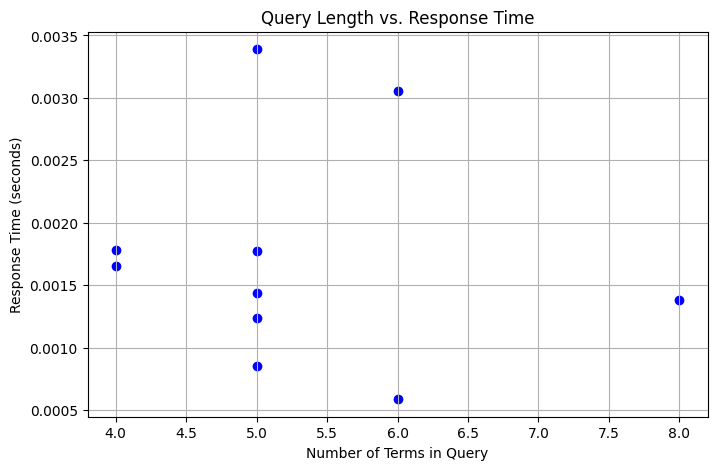

Plot generated successfully.


In [6]:
import matplotlib.pyplot as plt
import statistics

# --- Step 4: Evaluation Functions ---

# Mapping queries to Reuters categories for relevance checking
QUERY_CATEGORY_MAP = {
    1: ['crude', 'oil'],
    2: ['acq', 'bank'],
    3: ['interest', 'money-supply'],
    4: ['wheat', 'grain', 'corn'],
    5: ['gnp', 'cpi'],
    6: ['gold'],
    7: ['trade', 'ship'],
    8: ['earn'],
    9: ['money-fx', 'dlr'],
    10: ['trade']
}

QUERIES = [
    (1, "oil price increase in international markets"),
    (2, "bank mergers and acquisition news"),
    (3, "U.S. interest rate policy changes"),
    (4, "agricultural wheat production forecasts"),
    (5, "economic growth in Asia during 1980s"),
    (6, "gold trading and mining companies"),
    (7, "export regulations for electronics industry"),
    (8, "stock market crash predictions"),
    (9, "currency exchange fluctuations in Europe"),
    (10, "trade agreements between Japan and the U.S.")
]

def get_doc_categories(doc_id):
    return reuters.categories(doc_id)

def calculate_precision_at_k(results, target_categories, k=10):
    """
    Checks if top K docs contain the target category.
    """
    relevant_count = 0
    current_k = min(len(results), k)

    if current_k == 0: return 0.0

    for doc_id, score in results[:current_k]:
        doc_cats = get_doc_categories(doc_id)
        if any(target in doc_cats for target in target_categories):
            relevant_count += 1

    return relevant_count / current_k

def calculate_average_precision(results, target_categories):
    """
    Calculates Average Precision (AP) for a single query.
    """
    relevant_count = 0
    precision_sum = 0.0

    for i, (doc_id, score) in enumerate(results):
        doc_cats = get_doc_categories(doc_id)
        is_relevant = any(target in doc_cats for target in target_categories)

        if is_relevant:
            relevant_count += 1
            # Precision @ this rank
            precision_at_i = relevant_count / (i + 1)
            precision_sum += precision_at_i

    if relevant_count == 0:
        return 0.0

    return precision_sum / relevant_count

if __name__ == "__main__":
    print("\n" + "="*40)
    print("STEP 4: EVALUATION & TIMING")
    print("="*40)

    map_sum = 0.0
    query_times = []
    query_lengths = []

    print(f"{'ID':<3} {'Query (truncated)':<35} {'Time(s)':<10} {'P@10':<8} {'AP':<8}")
    print("-" * 70)

    for q_id, q_text in QUERIES:
        t0 = time.time()
        results = search(q_text, final_index, idf_values, top_k=50)
        t1 = time.time()

        elapsed = t1 - t0
        query_times.append(elapsed)

        q_len = len(word_tokenize(q_text))
        query_lengths.append(q_len)

        target_cats = QUERY_CATEGORY_MAP.get(q_id, [])
        p10 = calculate_precision_at_k(results, target_cats, k=10)
        ap = calculate_average_precision(results, target_cats)
        map_sum += ap

        print(f"{q_id:<3} {q_text[:33]:<35} {elapsed:.5f}    {p10:.2f}     {ap:.4f}")

    mean_response_time = statistics.mean(query_times)
    mean_avg_precision = map_sum / len(QUERIES)

    print("-" * 70)
    print(f"Mean Average Precision (MAP): {mean_avg_precision:.4f}")
    print(f"Average Response Time: {mean_response_time:.5f} seconds")

    # --- Visualization: Query Length vs Time ---
    print("\n[Data for Plotting]")
    print("Query Lengths:", query_lengths)
    print("Response Times:", query_times)

    try:
        plt.figure(figsize=(8, 5))
        plt.scatter(query_lengths, query_times, color='blue')
        plt.title('Query Length vs. Response Time')
        plt.xlabel('Number of Terms in Query')
        plt.ylabel('Response Time (seconds)')
        plt.grid(True)
        plt.show()
        print("Plot generated successfully.")
    except Exception as e:
        print("Could not generate plot (environment issue). Use the data above.")



In [7]:
QUERIES = [
    "oil price increase in international markets",
    "bank mergers and acquisition news",
    "U.S. interest rate policy changes",
    "agricultural wheat production forecasts",
    "economic growth in Asia during 1980s",
    "gold trading and mining companies",
    "export regulations for electronics industry",
    "stock market crash predictions",
    "currency exchange fluctuations in Europe",
    "trade agreements between Japan and the U.S."
]

print("--- Top 10 Retrieved Documents for Each Query ---\n")

for i, query_text in enumerate(QUERIES):
    print(f"Query {i+1}: {query_text}")
    print(f"{'Rank':<5} {'Doc ID':<20} {'Score':<10}")
    print("-" * 40)

    results = search(query_text, final_index, idf_values, top_k=10)

    for rank, (doc_id, score) in enumerate(results):
        print(f"{rank+1:<5} {doc_id:<20} {score:.4f}")

    print("\n" + "="*40 + "\n")


--- Top 10 Retrieved Documents for Each Query ---

Query 1: oil price increase in international markets
Rank  Doc ID               Score     
----------------------------------------
1     test/18746           0.3492
2     training/2775        0.3234
3     training/127         0.2933
4     training/6876        0.2833
5     training/3798        0.2793
6     training/248         0.2776
7     training/11723       0.2761
8     training/489         0.2760
9     test/19285           0.2754
10    test/20936           0.2655


Query 2: bank mergers and acquisition news
Rank  Doc ID               Score     
----------------------------------------
1     training/11981       0.3364
2     training/9640        0.2895
3     training/3377        0.2523
4     training/11812       0.2474
5     training/6914        0.2254
6     test/19796           0.2237
7     training/13043       0.2112
8     training/7433        0.2085
9     test/16644           0.2066
10    training/7568        0.1981


Query 3: U.